In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

print ('Import Libraries Success!')

Import Libraries Success!


In [3]:
ticker = 'AAPL'
df = yf.download(ticker, start='2022-01-01', end='2024-01-01')
print(df.shape)
df.head()

[*********************100%***********************]  1 of 1 completed

(501, 5)


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2022-01-03,177.939713,178.790267,173.735885,173.853197,104487900
2022-01-04,175.681396,178.848946,175.114365,178.545881,99310400
2022-01-05,171.008286,176.140880,170.734548,175.593406,94537600
2022-01-06,168.153595,171.379801,167.801645,168.837938,96904000
2022-01-07,168.319794,170.245740,167.205288,169.023694,86709100


In [4]:
df['Next_Close'] = df['Close'].shift(-1)
df = df.dropna()
features = ['Open', 'High', 'Low', 'Volume', 'Close']

X = df[features]
Y = df['Next_Close']

print('Features shape: ', X.shape)
print('Target shape: ', Y.shape)

Features shape:  (500, 5)
Target shape:  (500,)


In [11]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, shuffle=False)

print('Training samples:', len(X_train))
print('Testing samples:', len(X_test))

Training samples: 400
Testing samples: 100


In [16]:
# Using Linear Regression
model = LinearRegression()
model.fit(X_train, Y_train)

print('Model finished training!')
#Results: Mean Absolute Error: $1.89, R2 Score: 0.9166

Model finished training!


In [ ]:
#Alternative Using Random Forest
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, Y_train)
print('Model finished training!')
#Results: Mean Absolute Error: $2.01, R2 Score: 0.9066

Model finished training!


In [17]:
#test/eval model
Y_pred = model.predict(X_test)
mae = mean_absolute_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)

print(f'Mean Absolute Error: ${mae:.2f}')
print(f'R2 Score: {r2:.4f}')

Mean Absolute Error: $1.89
R2 Score: 0.9166


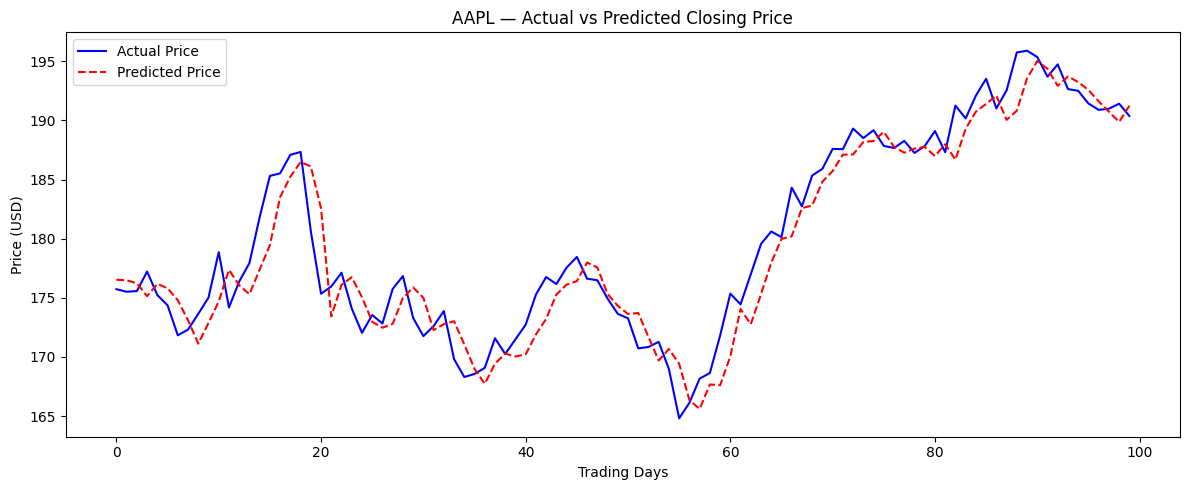

In [18]:
plt.figure(figsize=(12, 5))

plt.plot(Y_test.values, label='Actual Price', color='blue', linewidth=1.5)
plt.plot(Y_pred, label='Predicted Price', color='red', linewidth=1.5, linestyle='--')
plt.title(f'{ticker} — Actual vs Predicted Closing Price')
plt.xlabel('Trading Days')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()

plt.show()

## Task 2: Stock Price Prediction Summary

### Project Overview
In this task, we built a machine learning model to predict the next-day closing price of Apple (AAPL) stock using historical data from 2022 to 2024. This is a Regression problem because we are predicting a continuous numerical value (price).

### Data & Feature Engineering
- Data Source: Downloaded 2 years of daily stock data using `yfinance`.
- Target Variable: Created a `Next_Close` column by shifting the `Close` price up by one day. This allows the model to learn what tomorrow's price looks like based on today's data.
- Features Used: Open, High, Low, Volume, and Close prices.
- Data Splitting: Used an 80/20 split for training and testing. Crucially, we set `shuffle=False` because stock data is time-series; we must train on past data and test on future data.

### Model Training
I trained two types of models:
1. Linear Regression: Finds a straight-line relationship between features and price.
2. Random Forest Regressor: Uses an ensemble of decision trees.
### Model Comparison & Results
I trained two different models to see which performed better:

| Model | Mean Absolute Error (MAE) | R² Score |
| Linear Regression | $1.89 | 0.9166 |
| Random Forest | $2.01 | 0.9066 |

### Analysis of Findings
1. Linear Regression Performed Better: Surprisingly, the simpler Linear Regression model outperformed the more complex Random Forest in this specific instance. It had a lower error ($1.89 vs $2.01) and a higher R² score (0.9166 vs 0.9066).
2. High Accuracy: Both models achieved an R² score above 0.90, which is considered excellent for financial data. This means both models successfully captured the general trend of the stock price.
3. Interpretation: The MAE of ~$1.90 means that on average, our predictions were off by less than $2.00 per share. Given that AAPL stock often trades between $150–$200, this is a very tight margin of error.

### Visual Analysis
The "Actual vs. Predicted" plot confirms these metrics:
- The Red Dashed Line (Predictions) closely follows the Blue Line (Actual Prices).
- Because Linear Regression had the higher R², its line likely tracks the major trends slightly more smoothly than the Random Forest, which may have overfit to some minor noise in the training data.

### Conclusion
While Random Forest is often preferred for complex non-linear data, Linear Regression proved to be the most efficient and accurate model for this specific 2-year AAPL dataset. This suggests that the relationship between daily OHLCV features and the next day's close is largely linear during this period.

In [22]:
#Testing both models against the real data
# Model 1: Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, Y_train)

# Model 2: Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, Y_train)

print("Both models trained successfully!")

Both models trained successfully!


In [23]:
y_pred_lr = lr_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

mae_lr = mean_absolute_error(Y_test, y_pred_lr)
r2_lr = r2_score(Y_test, y_pred_lr)

mae_rf = mean_absolute_error(Y_test, y_pred_rf)
r2_rf = r2_score(Y_test, y_pred_rf)

print("Linear Regression Results:")
print(f"Mean Absolute Error: ${mae_lr:.2f}")
print(f"R2 Score: {r2_lr:.4f}")

print(f"\nRandom Forest Results")
print(f"Mean Absolute Error: ${mae_rf:.2f}")
print(f"R2 Score: {r2_rf:.4f}")

Linear Regression Results:
Mean Absolute Error: $1.89
R2 Score: 0.9166

Random Forest Results
Mean Absolute Error: $2.01
R2 Score: 0.9066


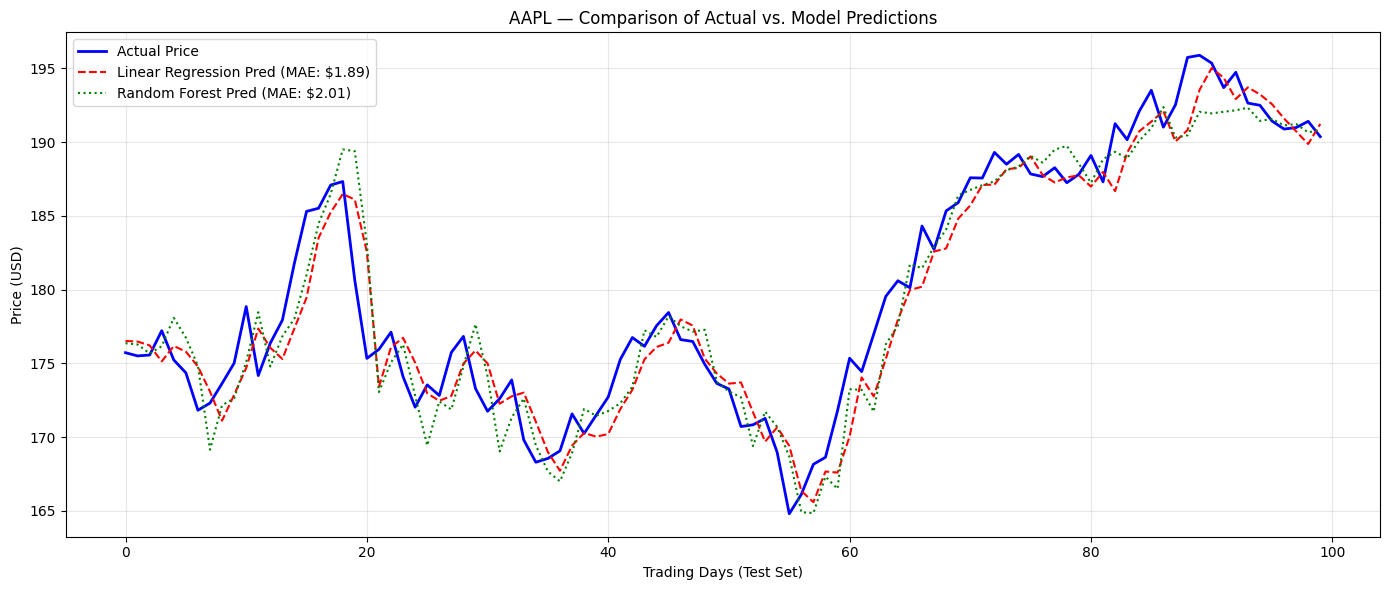

In [24]:
plt.figure(figsize=(14, 6))
plt.plot(Y_test.values, label='Actual Price', color='blue', linewidth=2)

plt.plot(y_pred_lr, label=f'Linear Regression Pred (MAE: ${mae_lr:.2f})', 
         color='red', linestyle='--', linewidth=1.5)

plt.plot(y_pred_rf, label=f'Random Forest Pred (MAE: ${mae_rf:.2f})', 
         color='green', linestyle=':', linewidth=1.5)

plt.title(f'{ticker} — Comparison of Actual vs. Model Predictions')
plt.xlabel('Trading Days (Test Set)')
plt.ylabel('Price (USD)')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()